##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [6]:
!pip -q install keras keras-hub tensorflow tensorflow-text

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Please upload 5 images from your computer:


Saving apple.jpg to apple (4).jpg
Saving banana.jpg to banana (4).jpg
Saving dog.jpg to dog (4).jpg
Saving sports car.jpg to sports car (4).jpg
Saving tabby cat.jpg to tabby cat (4).jpg

Image File           | Predicted Label           | Correct? (Yes/No)
---------------------------------------------------------------------------
apple (4).jpg        | Granny_Smith              | ______
banana (4).jpg       | banana                    | ______
dog (4).jpg          | golden_retriever          | ______
sports car (4).jpg   | sports_car                | ______
tabby cat (4).jpg    | tabby                     | ______


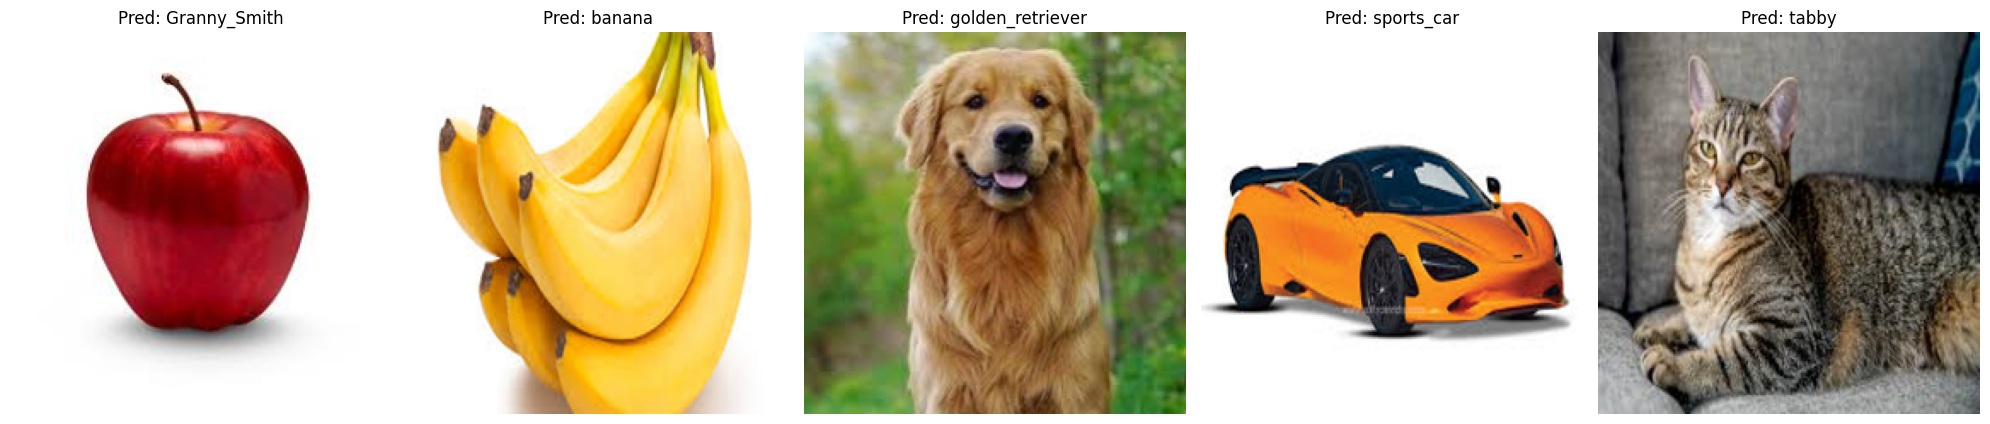

In [16]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import keras
import keras_hub
from google.colab import files

# --- 1. Load Pretrained ViT Model ---
model_preset = "vit_base_patch16_224_imagenet"
classifier = keras_hub.models.ViTImageClassifier.from_preset(model_preset, load_weights=True)

# --- 2. Load ImageNet Labels ---
labels_url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
labels_path = keras.utils.get_file("imagenet_class_index_final.json", labels_url)
with open(labels_path) as f:
    class_idx = json.load(f)
imagenet_labels = [class_idx[str(i)][1] for i in range(1000)]

# --- 3. Upload Files from Device ---
print("Please upload 5 images from your computer:")
uploaded = files.upload()
uploaded_filenames = list(uploaded.keys())

# --- 4. Run Inference and Print Results ---
print(f"\n{'Image File':<20} | {'Predicted Label':<25} | {'Correct? (Yes/No)'}")
print("-" * 75)

plt.figure(figsize=(20, 6))

for i, filename in enumerate(uploaded_filenames):
    if i >= 5: break # Limit to first 5 images for the lab requirement

    try:
        # Load and resize
        img = PIL.Image.open(filename).convert("RGB")
        img_resized = img.resize((224, 224))
        img_array = np.array(img_resized).astype("float32")

        # Predict (KerasHub preprocessor handles normalization automatically)
        predictions = classifier.predict(np.expand_dims(img_array, axis=0), verbose=0)
        predicted_idx = np.argmax(predictions, axis=-1)[0]
        predicted_label = imagenet_labels[predicted_idx]

        # Print for your lab table
        print(f"{filename:<20} | {predicted_label:<25} | ______")

        # Visualization
        plt.subplot(1, 5, i + 1)
        plt.imshow(img_resized)
        plt.title(f"Pred: {predicted_label}")
        plt.axis("off")

    except Exception as e:
        print(f"Error processing {filename}: {e}")

plt.tight_layout()
plt.show()

Please upload your 5 images:


Saving apple.jpg to apple (6).jpg
Saving banana.jpg to banana (6).jpg
Saving golden retriever.jpg to golden retriever.jpg
Saving sports car.jpg to sports car (6).jpg
Saving tabby cat.jpg to tabby cat (6).jpg

Image File           | Predicted Label           | True Label      | Correct?
-------------------------------------------------------------------------------------
apple (6).jpg        | Granny Smith              | Apple           | No
banana (6).jpg       | Banana                    | Banana          | Yes
golden retriever.jpg | Golden Retriever          | Golden Retriever | Yes
sports car (6).jpg   | Sports Car                | Sports Car      | Yes
tabby cat (6).jpg    | Tabby                     | Tabby Cat       | Yes


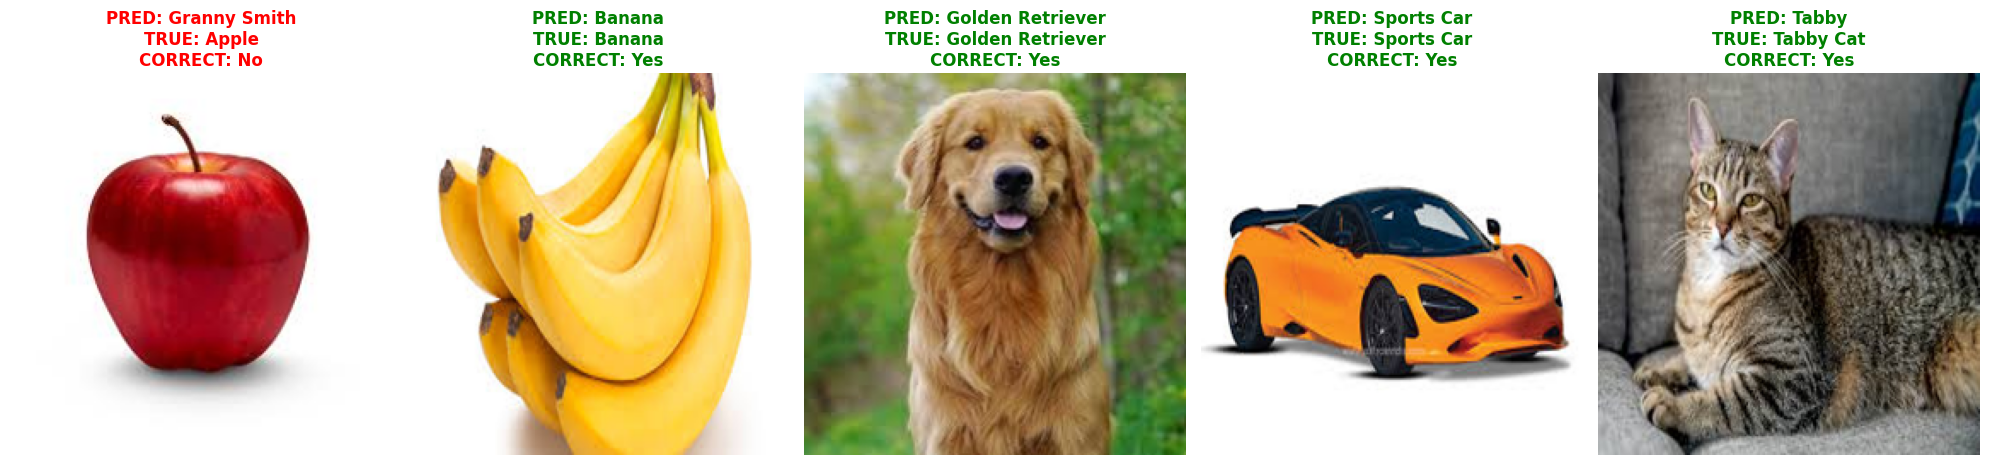

In [18]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import keras
import keras_hub
from google.colab import files

# --- 1. Load Pretrained ViT Model ---
model_preset = "vit_base_patch16_224_imagenet"
classifier = keras_hub.models.ViTImageClassifier.from_preset(model_preset, load_weights=True)

# --- 2. Load ImageNet Labels ---
labels_url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
labels_path = keras.utils.get_file("imagenet_labels.json", labels_url)
with open(labels_path) as f:
    class_idx = json.load(f)
imagenet_labels = [class_idx[str(i)][1] for i in range(1000)]

# Helper to clean filename into a "True Label" (e.g., "apple (4).jpg" -> "Apple")
def get_true_label(filename):
    name = os.path.splitext(filename)[0]
    name = re.sub(r'\s\(\d+\)', '', name) # Remove (1), (2), etc.
    return name.replace('_', ' ').strip().title()

# --- 3. Upload Files ---
print("Please upload your 5 images:")
uploaded = files.upload()
uploaded_filenames = list(uploaded.keys())[:5] # Take only the first 5

# --- 4. Run Inference and Plot ---
print(f"\n{'Image File':<20} | {'Predicted Label':<25} | {'True Label':<15} | {'Correct?'}")
print("-" * 85)

plt.figure(figsize=(20, 8))

for i, filename in enumerate(uploaded_filenames):
    try:
        # 1. Process Image
        img = PIL.Image.open(filename).convert("RGB")
        img_resized = img.resize((224, 224))
        img_array = np.array(img_resized).astype("float32")

        # 2. Predict
        predictions = classifier.predict(np.expand_dims(img_array, axis=0), verbose=0)
        predicted_idx = np.argmax(predictions, axis=-1)[0]
        predicted_label = imagenet_labels[predicted_idx].replace('_', ' ').title()

        # 3. Determine Correctness (Fuzzy Match)
        true_label = get_true_label(filename)
        is_correct = true_label.lower() in predicted_label.lower() or predicted_label.lower() in true_label.lower()
        status = "Yes" if is_correct else "No"
        color = "green" if is_correct else "red"

        # 4. Print Table Row
        print(f"{filename:<20} | {predicted_label:<25} | {true_label:<15} | {status}")

        # 5. Add to Plot
        plt.subplot(1, 5, i + 1)
        plt.imshow(img_resized)
        # Title includes the Correctness status
        plt.title(f"PRED: {predicted_label}\nTRUE: {true_label}\nCORRECT: {status}",
                  color=color, fontsize=12, fontweight='bold')
        plt.axis("off")

    except Exception as e:
        print(f"Error processing {filename}: {e}")

plt.tight_layout()
plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
